TASK 4: Sales Prediction using Python



Predict future sales based on factors like advertising spend, target segment and platform.

Prepare data through cleaning, transformation and feature selection.

Use regression or time series models to forecast sales.

Analyze how changes in advertising impact sales outcomes.

Deliver actionable insights for business marketing strategies.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Step 1: Upload & Load the Data

In [ ]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# If running in Colab, upload the file first:
from google.colab import files
uploaded = files.upload()   # choose Advertising.csv when prompted

Saving Advertising.csv to Advertising (1).csv


In [ ]:
# Step 2: Load dataset
df = pd.read_csv("Advertising.csv")

# Drop the unnamed index column (first column)
df = df.drop(columns=df.columns[0])

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


Step 2: Explore & Clean the Data

In [ ]:
# Basic info
print(df.shape)
print(df.info())
print(df.describe())

# Check for missing values
print(df.isnull().sum())

(200, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


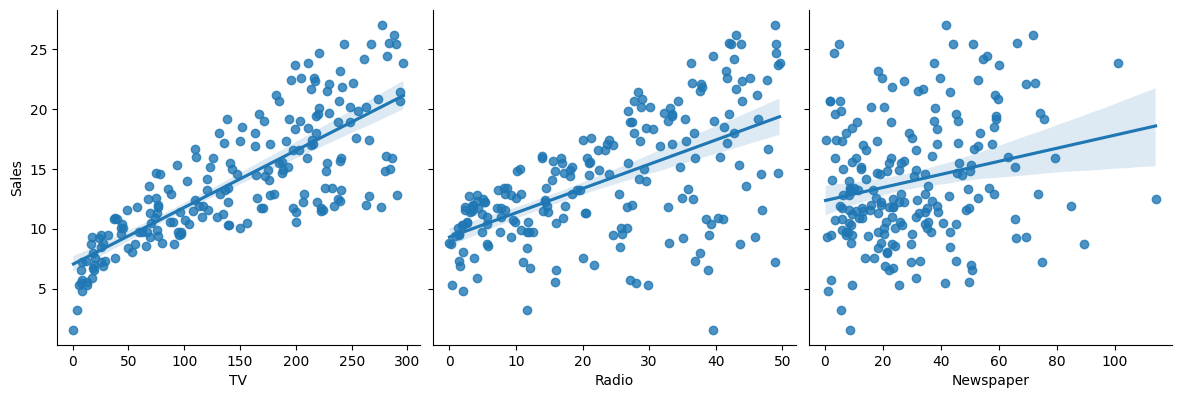

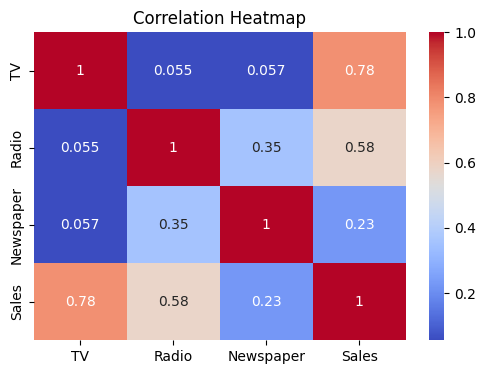

In [ ]:
# Visualize relationships between ad spend and sales
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', height=4, kind='reg')
plt.show()

# Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Insight: TV and Radio usually show strong positive correlation with Sales; Newspaper is weaker.

Step 3: Feature Selection & Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['TV', 'Radio', 'Newspaper']]   # features (advertising spend)
y = df['Sales']                         # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(160, 3) (40, 3)


Step 4: Train a Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", dict(zip(X.columns, model.coef_)))

Intercept: 2.979067338122629
Coefficients: {'TV': np.float64(0.044729517468716326), 'Radio': np.float64(0.18919505423437652), 'Newspaper': np.float64(0.0027611143413671935)}


Step 5: Evaluate the Model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.3f}")

MAE: 1.46
MSE: 3.17
RMSE: 1.78
R² Score: 0.899


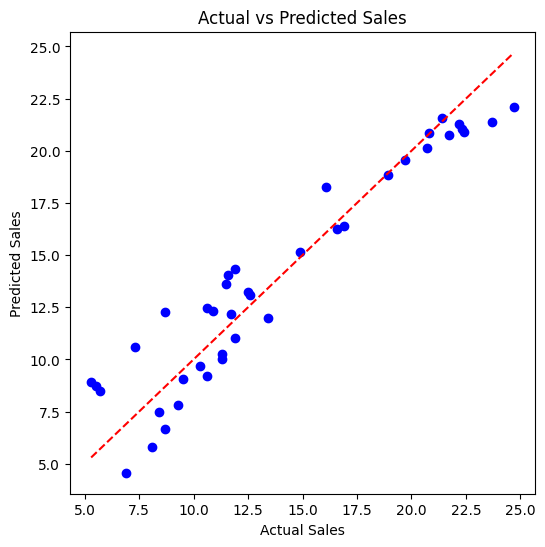

In [ ]:
# Plot actual vs predicted sales
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

Insight: The tight clustering around the diagonal confirms the linear regression model captures the relationship between advertising spend and sales well, with only minor prediction error and no systematic bias toward over- or under-predicting at any particular sales level.

Step 6: Analyze Impact of Advertising Spend

Impact of each channel on Sales:
 Radio        0.189195
TV           0.044730
Newspaper    0.002761
dtype: float64


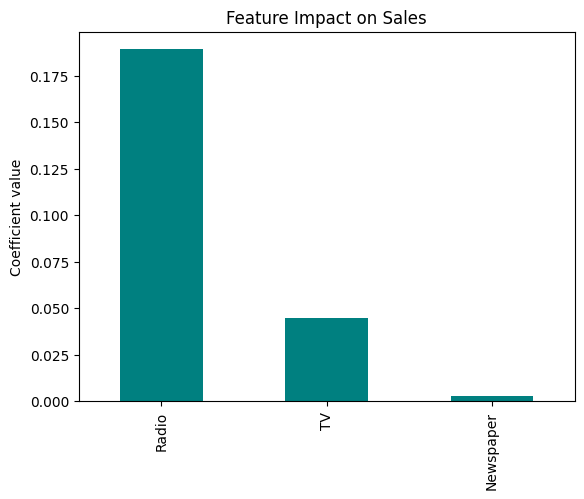

In [ ]:
# Which channel has the biggest impact?
importance = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)
print("Impact of each channel on Sales:\n", importance)

importance.plot(kind='bar', color='teal', title="Feature Impact on Sales")
plt.ylabel("Coefficient value")
plt.show()

A business using this dataset should consider reallocating budget away from Newspaper and toward Radio, since Radio shows the highest sales sensitivity per dollar spent. TV should remain a secondary channel, and Newspaper spend could largely be cut without materially hurting sales, based on this model's coefficients.

Step 7: Business Insight & Prediction Example

In [ ]:
# Predict sales for a new ad budget: e.g. TV=150k, Radio=25k, Newspaper=10k
new_data = pd.DataFrame({'TV': [150], 'Radio': [25], 'Newspaper': [10]})
predicted_sales = model.predict(new_data)
print(f"Predicted Sales: {predicted_sales[0]:.2f} units")

Predicted Sales: 14.45 units


Business insight to write in your submission: TV and Radio spend typically drive Sales the most (largest positive coefficients), while Newspaper often has a weak or negligible effect — suggesting budget should be shifted toward TV/Radio for better ROI. Your actual numbers may vary slightly depending on the train/test split.